# 04 시간 요약 — VLM 기반 비디오 요약 기술 (IPAD 실습)

비디오 시공간 흐름의 압축과 Vision-Language Model 분석

| Part | 주제 |
|------|------|
| 1 | 비디오 요약 핵심 — 정적(Keyframe) vs 동적(Video Skimming) |
| 2 | VLM 융합 — 프레임 토큰화 · CLIP 임베딩 · 토큰 압축 |
| 3 | 시간 세그멘테이션 & 적응형 키프레임 (AKS · T* · Shot Boundary) |
| 4 | VLM 기반 요약 파이프라인 — 쿼리 유도 선별 + 텍스트 요약 |

### IPAD 실습 데이터 (약 11 MB)

1. 노트북과 **같은 폴더**에 `IPAD_sample.zip` 배치
2. 실행 시 자동 압축 해제 → `IPAD_Sample/`
3. 구조: `IPAD_Sample/{설비명}/training/frames/{클립ID}/*.jpg`


### 본 실습에서 다루는 기술

| 기법 | 한 줄 설명 | 코드에서의 역할 |
|------|-----------|----------------|
| **정적 요약 (Keyframe)** | 대표 프레임 subset 추출 | `select_keyframes_histogram`, `select_keyframes_ssim` |
| **동적 요약 (Skimming)** | 중요 구간 클립 병합 | `build_skim_timeline`, `merge_segments_to_summary` |
| **Shot Boundary** | 장면 전환점 탐지 | `detect_shot_boundaries` (히스토그램·픽셀 차) |
| **시간 세그멘테이션** | 의미 단위 구간 분할 | `segment_by_change_points`, `kmedoids_segments` |
| **CLIP Relevance** | 텍스트-프레임 유사도 | `score_frames_with_clip` |
| **AKS 적응형 샘플링** | relevance + coverage 최적화 | `adaptive_keyframe_sampling` |
| **T* Temporal Search** | 그리드 줌인 탐색 | `temporal_grid_search` |
| **토큰 압축 (Projector)** | N프레임 → K토큰 | `SpatiotemporalProjector` |
| **VLM 요약** | 선별 프레임 → 캡션/요약 | `generate_clip_summary`, BLIP-2 (선택) |

핵심: 긴 비디오는 **전체를 LLM에 넣을 수 없으므로**, 선별·세그멘테이션·토큰 압축이 VLM 파이프라인의 전제입니다.


In [1]:
# !pip install -q -r requirements.txt
# !pip install scikit-image  # SSIM (선택 — 없으면 MSE fallback)
# scikit-image: 구조적 유사도(SSIM) 계산용. 미설치 시 MSE로 대체됩니다.


In [2]:
from __future__ import annotations

# ── 표준 라이브러리 ──────────────────────────────────────────────────────────
import json          # manifest JSON 직렬화
import os
import platform      # OS별 한글 폰트 분기
import subprocess    # Colab apt-get 폰트 설치
import textwrap      # VLM 입력 카드 제목 줄바꿈
import zipfile       # IPAD_sample.zip 자동 해제
from dataclasses import dataclass, field
from enum import Enum
from pathlib import Path

# ── 서드파티 ─────────────────────────────────────────────────────────────────
import cv2           # 프레임 I/O, 히스토그램, 색공간 변환
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.gridspec import GridSpec   # 다중 서브플롯 레이아웃
from PIL import Image                      # CLIP/BLIP 입력용 RGB 이미지
from scipy import signal as sp_signal      # motion peak 탐지 (find_peaks)
from scipy.spatial.distance import cdist   # K-Medoids 거리 행렬

# SSIM: scikit-image 있으면 구조적 유사도, 없으면 MSE fallback
try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except ImportError:
    HAS_SKIMAGE = False

# ── 경로·모델 설정 ───────────────────────────────────────────────────────────
# IPAD zip 파일명 후보 (Windows 대소문자 무시)
IPAD_ZIP_NAMES = ("IPAD_sample.zip", "IPAD_Sample.zip")
IPAD_EXTRACT_DIR = Path("IPAD_Sample")   # zip 내부 최상위 폴더명과 일치
IPAD_SEARCH_PATHS = [IPAD_EXTRACT_DIR, Path("IPAD_sample"), Path("IPAD")]

# 분석 산출물 저장 경로
OUTPUT_DIR = Path("output_vlm_summary")
FIG_DIR = OUTPUT_DIR / "figures"
KEYFRAME_DIR = OUTPUT_DIR / "keyframes"
SEGMENT_DIR = OUTPUT_DIR / "segments"
MANIFEST_PATH = OUTPUT_DIR / "summary_manifest.json"

# 분석 대상 클립 (None이면 discover 후 자동 선택)
SELECTED_DEVICE: str | None = "R01"
SELECTED_CLIP: str | None = "01"
FPS_ASSUMED = 30.0   # 프레임 인덱스 → 초 변환 가정 fps

# 키프레임·세그멘테이션 파라미터
NUM_KEYFRAMES = 12       # 정적/적응형 키프레임 최대 개수
SHOT_THRESHOLD = 0.45    # Shot boundary: BHATTACHARYYA 히스토그램 거리 임계값
MIN_SEGMENT_LEN = 8      # Change-point: 최소 구간 길이(프레임)
NUM_VLM_FRAMES = 8       # VLM 입력·토큰 압축 budget
CLIP_MODEL_ID = "openai/clip-vit-base-patch32"
BLIP_MODEL_ID = "Salesforce/blip-image-captioning-base"

RUN_CLIP = True          # False면 histogram fallback으로 relevance 계산
RUN_BLIP = False  # GPU·다운로드 부담 — 필요 시 True

# CLIP 텍스트-이미지 relevance 쿼리 (CLIP pretrain은 영문 위주)
SUMMARY_QUERY = "industrial machine operation and motion"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 출력 디렉터리 선생성 (savefig / imwrite 경로 오류 방지)
for d in (OUTPUT_DIR, FIG_DIR, KEYFRAME_DIR, SEGMENT_DIR):
    d.mkdir(parents=True, exist_ok=True)


def is_running_in_colab() -> bool:
    """Google Colab 런타임 여부 — 한글 폰트 apt 설치 분기용."""
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def setup_matplotlib_korean() -> None:
    """
    matplotlib 한글·마이너스 기호 깨짐 방지.
    OS별 고딕 폰트를 탐색하고, 없으면 ttf를 직접 등록합니다.
    """
    from matplotlib import font_manager
    if is_running_in_colab():
        subprocess.run(
            ["apt-get", "-qq", "-y", "install", "fonts-nanum"],
            check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
        font_manager._load_fontmanager(try_read_cache=False)
    if platform.system() == "Windows":
        candidates = ["Malgun Gothic", "NanumGothic", "Gulim"]
        fallback = Path(os.environ.get("WINDIR", r"C:\Windows")) / "Fonts" / "malgun.ttf"
    elif platform.system() == "Darwin":
        candidates = ["AppleGothic", "Apple SD Gothic Neo"]
        fallback = None
    else:
        candidates = ["NanumGothic", "NanumBarunGothic"]
        fallback = Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    available = {f.name for f in font_manager.fontManager.ttflist}
    chosen = next((n for n in candidates if n in available), None)
    if chosen:
        plt.rcParams["font.family"] = chosen
    elif fallback and fallback.exists():
        font_manager.fontManager.addfont(str(fallback))
        plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(fallback)).get_name()
    plt.rcParams["axes.unicode_minus"] = False


setup_matplotlib_korean()
print(f"환경 설정 완료 | device={DEVICE} | skimage={HAS_SKIMAGE}")


환경 설정 완료 | device=cuda | skimage=True


In [3]:
# IPAD가 제공하는 프레임 이미지 확장자
FRAME_EXTS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}


@dataclass
class IpadClip:
    """IPAD 프레임 시퀀스 클립 메타데이터 (설비 1개 영상 = 프레임 폴더)."""
    device: str           # 설비 코드 (예: R01)
    split: str            # training / testing
    clip_id: str          # 클립 폴더명 (예: 01)
    frame_dir: Path       # .../frames/{clip_id}/ 경로
    frame_paths: list[Path]  # 시간순 정렬된 jpg 경로 목록

    @property
    def num_frames(self) -> int:
        return len(self.frame_paths)


def _is_valid_ipad_root(base: Path) -> bool:
    """하위에 `{설비}/training/frames/` 구조가 있으면 유효한 IPAD 루트."""
    if not base.is_dir():
        return False
    for child in base.iterdir():
        if child.is_dir() and (child / "training" / "frames").is_dir():
            return True
    return (base / "training" / "frames").is_dir()


def find_ipad_zip() -> Path | None:
    """현재 작업 디렉터리에서 IPAD_sample.zip 파일을 찾는다."""
    cwd = Path(".")
    for name in IPAD_ZIP_NAMES:
        p = cwd / name
        if p.is_file():
            return p
    return None


def ensure_ipad_sample() -> Path | None:
    """IPAD_sample.zip을 찾아 필요 시 압축 해제. 이미 있으면 재추출하지 않음."""
    for base in IPAD_SEARCH_PATHS:
        if _is_valid_ipad_root(base):
            return base

    zpath = find_ipad_zip()
    if zpath is None:
        return None

    print(f"[IPAD] {zpath.name} 압축 해제 중 -> {Path('.').resolve()}")
    with zipfile.ZipFile(zpath, "r") as zf:
        zf.extractall(".")

    for base in IPAD_SEARCH_PATHS:
        if _is_valid_ipad_root(base):
            print(f"[IPAD] 데이터 준비 완료: {base.resolve()}")
            return base
    return None


def find_ipad_root() -> Path | None:
    """IPAD_sample.zip 자동 해제 후 데이터셋 루트를 탐색한다."""
    ensure_ipad_sample()
    for base in IPAD_SEARCH_PATHS:
        if not base.exists():
            continue
        if _is_valid_ipad_root(base):
            return base
        if (base / "training" / "frames").is_dir():
            return base.parent
    return None


def _list_frame_files(frame_dir: Path) -> list[Path]:
    """클립 폴더 내 이미지 파일만 필터링 후 파일명 기준 정렬."""
    files = [p for p in frame_dir.iterdir() if p.suffix.lower() in FRAME_EXTS]
    return sorted(files, key=lambda p: p.name)


def discover_clips(root: Path) -> list[IpadClip]:
    """IPAD 루트 아래 모든 설비·split·클립을 순회해 IpadClip 목록 생성."""
    clips: list[IpadClip] = []
    devices = sorted(d for d in root.iterdir() if d.is_dir())
    for dev in devices:
        for split in ("training", "testing"):
            frames_root = dev / split / "frames"
            if not frames_root.is_dir():
                continue
            for clip_dir in sorted(d for d in frames_root.iterdir() if d.is_dir()):
                paths = _list_frame_files(clip_dir)
                if paths:
                    clips.append(IpadClip(dev.name, split, clip_dir.name, clip_dir, paths))
    return clips


def resolve_ipad_session(
    device: str | None = None,
    clip_id: str | None = None,
) -> tuple[Path, IpadClip]:
    """IPAD 루트와 분석 대상 클립 1개 반환 (training 우선)."""
    root = find_ipad_root()
    if root is None:
        raise FileNotFoundError("IPAD_sample.zip을 노트북 폴더에 배치하세요.")
    clips = discover_clips(root)
    if not clips:
        raise FileNotFoundError(f"클립 없음: {root}")
    train_clips = [c for c in clips if c.split == "training"]
    pool = train_clips or clips
    if device:
        pool = [c for c in pool if c.device == device] or pool
    if clip_id:
        pool = [c for c in pool if c.clip_id == clip_id] or pool
    pool = sorted(pool, key=lambda c: (c.device, c.clip_id))
    clip = pool[0]
    return root, clip


def load_clip_frames(clip: IpadClip, max_frames: int | None = None) -> list[np.ndarray]:
    """클립 jpg 경로 목록을 OpenCV BGR ndarray 리스트로 로드."""
    paths = clip.frame_paths if max_frames is None else clip.frame_paths[:max_frames]
    frames = []
    for p in paths:
        img = cv2.imread(str(p))
        if img is not None:
            frames.append(img)
    return frames


def frame_to_rgb(frame_bgr: np.ndarray) -> np.ndarray:
    """OpenCV BGR → matplotlib/PIL용 RGB."""
    return cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)


def compute_motion_energy(frames: list[np.ndarray]) -> np.ndarray:
    """
    연속 프레임 그레이스케일 차분 평균 — 움직임 강도 1차 신호.
    길이 = len(frames) - 1.
    """
    energy = []
    for i in range(len(frames) - 1):
        g1 = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY)
        g2 = cv2.cvtColor(frames[i + 1], cv2.COLOR_BGR2GRAY)
        energy.append(float(np.mean(cv2.absdiff(g1, g2))))
    return np.asarray(energy, dtype=np.float32)


def compute_color_histogram(frame_bgr: np.ndarray, bins: int = 32) -> np.ndarray:
    """HSV 2D 히스토그램 — 장면 변화·키프레임 중복 제거에 사용."""
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1], None, [bins, bins], [0, 180, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()


def histogram_distance(h1: np.ndarray, h2: np.ndarray) -> float:
    """BHATTACHARYYA 거리 — 0=유사, 1=상이."""
    return float(cv2.compareHist(h1.astype(np.float32), h2.astype(np.float32), cv2.HISTCMP_BHATTACHARYYA))


## Part 1 — 비디오 요약의 핵심 개념

교재 **정적 요약(Keyframe-based)** vs **동적 요약(Video Skimming)** 두 패러다임을 IPAD 설비 영상에 적용합니다.

- **정적**: Color Histogram · Pixel Difference · SSIM으로 중복 제거 후 대표 프레임 선별
- **동적**: Shot boundary + Motion importance로 구간을 나누고, 상위 구간을 타임라인으로 병합

---

### 이 섹션에서 쓰는 기술 — 용어 정리

| 약어/용어 | 원문 (Full Name) | 쉬운 설명 | 코드에서 |
|-----------|------------------|-----------|----------|
| **Keyframe** | Key Frame | 영상 전체를 대표하는 ‘핵심 한 장’. 앨범 표지처럼 내용을 요약하는 대표 이미지 | `select_keyframes_*` |
| **정적 요약** | Static / Keyframe-based Summarization | 움직임 없이 **대표 사진 몇 장**만 뽑아 빠르게 훑어보는 방식. 검색·미리보기·메타데이터에 유리 | Histogram, SSIM, Motion peak |
| **동적 요약** | Dynamic / Video Skimming Summarization | **짧은 클립 구간**을 이어 붙여 ‘축약 영상’을 만드는 방식. 시간 흐름·내러티브 유지 | Shot boundary, Skimming |
| **HSV** | Hue, Saturation, Value | 색을 ‘색상·채도·명도’로 나눈 색공간. 조명 변화에 Histogram이 덜 흔들림 | `compute_color_histogram` |
| **Color Histogram** | Color Histogram | 프레임 색 분포를 숫자 벡터로 요약. 비슷한 장면은 histogram이 비슷함 | 장면 변화·중복 제거 |
| **BHATTACHARYYA** | Bhattacharyya Distance | 두 histogram이 얼마나 다른지 재는 거리(0=같음, 1=다름). OpenCV `HISTCMP_BHATTACHARYYA` | `histogram_distance` |
| **SSIM** | Structural Similarity Index Measure | 구조적 유사도. 사람 눈에 ‘비슷한 그림’인지 측정(MSE보다 지각적으로 자연스러움) | `select_keyframes_ssim` |
| **MSE** | Mean Squared Error | 픽셀 차이 제곱 평균. SSIM 라이브러리 없을 때 fallback | `frame_pair_dissimilarity` |
| **Motion Energy** | Motion Energy | 연속 프레임 차분으로 **움직임 강도** 시계열 생성. 설비 동작 peak 탐지에 사용 | `compute_motion_energy` |
| **Shot Boundary** | Shot Boundary Detection | 장면·카메라 컷이 바뀌는 경계점. histogram 급변으로 근사 탐지 | `detect_shot_boundaries` |
| **Video Skimming** | Video Skimming | 중요도 높은 구간만 골라 **타임라인 순서**로 남기는 동적 요약 | `build_skim_timeline` |
| **IPAD** | Industrial Process Anomaly Detection | 산업 설비 이상 탐지용 프레임 시퀀스 데이터셋(본 실습: R01/01 샘플) | `resolve_ipad_session` |

> **한 줄 요약:** 정적 요약은 “어떤 **프레임**이 중요한가?”, 동적 요약은 “어떤 **구간**이 중요한가?”를 묻습니다. IPAD 설비 영상은 주기적 motion이 크므로 **Histogram(색·장면)** 과 **Motion(동작)** 을 함께 보면 효과적입니다.


In [4]:
# ── IPAD 클립 로드 ──
# resolve_ipad_session: zip 자동 해제 → train 클립 메타데이터 확보
IPAD_ROOT, CLIP_META = resolve_ipad_session(SELECTED_DEVICE, SELECTED_CLIP)
# BGR 프레임 리스트 — 키프레임·세그멘테이션·CLIP의 공통 입력
FRAMES = load_clip_frames(CLIP_META)
# Motion Energy — 동적 요약·change-point·motion peak에 사용
MOTION = compute_motion_energy(FRAMES)

print(f"IPAD root : {IPAD_ROOT}")
print(f"클립      : {CLIP_META.device}/{CLIP_META.split}/{CLIP_META.clip_id}")
print(f"프레임 수 : {len(FRAMES)} | Motion Energy 길이: {len(MOTION)}")


IPAD root : IPAD_Sample
클립      : R01/training/01
프레임 수 : 207 | Motion Energy 길이: 206


In [5]:
# ── 1-1. 정적 요약: Color Histogram 기반 키프레임 ──
# 교재 '정적 요약(Keyframe-based)': 대표 still image subset 추출

def select_keyframes_histogram(
    frames: list[np.ndarray],
    k: int,
    min_gap: int = 5,
) -> list[int]:
    """BHATTACHARYYA 거리가 큰 프레임을 순차 선택 (중복 제거)."""
    if len(frames) <= k:
        return list(range(len(frames)))
    hists = [compute_color_histogram(f) for f in frames]
    selected = [0]  # 첫 프레임을 anchor로 포함
    while len(selected) < k:
        best_idx, best_score = -1, -1.0
        for i in range(len(frames)):
            if i in selected:
                continue
            # min_gap: 시간적으로 너무 가까운 프레임 제외 (중복 방지)
            if any(abs(i - s) < min_gap for s in selected):
                continue
            # 이미 선택된 프레임들과의 최소 거리 = '다양성' 점수
            score = min(histogram_distance(hists[i], hists[s]) for s in selected)
            if score > best_score:
                best_idx, best_score = i, score
        if best_idx < 0:
            break
        selected.append(best_idx)
    return sorted(selected)


def frame_pair_dissimilarity(f1: np.ndarray, f2: np.ndarray) -> float:
    """두 프레임 간 구조/픽셀 차이 — SSIM 역수 또는 정규화 MSE."""
    g1 = cv2.cvtColor(f1, cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(f2, cv2.COLOR_BGR2GRAY)
    if HAS_SKIMAGE:
        s = ssim_fn(g1, g2, data_range=255)
        return 1.0 - float(s)
    return float(np.mean((g1.astype(np.float32) - g2.astype(np.float32)) ** 2) / (255.0 ** 2))


def select_keyframes_ssim(
    frames: list[np.ndarray],
    k: int,
    min_gap: int = 5,
) -> list[int]:
    """SSIM(또는 MSE) 기반 greedy 대표 프레임 선택."""
    if len(frames) <= k:
        return list(range(len(frames)))
    selected = [0]
    while len(selected) < k:
        best_idx, best_score = -1, -1.0
        for i in range(len(frames)):
            if i in selected:
                continue
            if any(abs(i - s) < min_gap for s in selected):
                continue
            score = min(frame_pair_dissimilarity(frames[i], frames[s]) for s in selected)
            if score > best_score:
                best_idx, best_score = i, score
        if best_idx < 0:
            break
        selected.append(best_idx)
    return sorted(selected)


def select_keyframes_motion_topk(frames: list[np.ndarray], motion: np.ndarray, k: int) -> list[int]:
    """Motion Energy peak 프레임 — 동적 변화가 큰 순간(설비 동작 peak)."""
    if len(motion) == 0:
        return select_keyframes_histogram(frames, k)
    peaks, _ = sp_signal.find_peaks(motion, distance=max(3, len(motion) // (k * 2)))
    if len(peaks) == 0:
        peaks = np.argsort(motion)[-k:]
    ranked = sorted(peaks, key=lambda i: motion[i], reverse=True)[:k]
    return sorted(int(i) for i in ranked)


# 세 가지 정적 키프레임 방법 비교 실행
kf_hist = select_keyframes_histogram(FRAMES, NUM_KEYFRAMES)
kf_ssim = select_keyframes_ssim(FRAMES, NUM_KEYFRAMES)
kf_motion = select_keyframes_motion_topk(FRAMES, MOTION, NUM_KEYFRAMES)

print("Histogram 키프레임:", kf_hist[:8], "...")
print("SSIM 키프레임    :", kf_ssim[:8], "...")
print("Motion Top-K     :", kf_motion)


Histogram 키프레임: [0, 12, 28, 39, 62, 91, 127, 150] ...
SSIM 키프레임    : [0, 44, 69, 96, 107, 116, 124, 130] ...
Motion Top-K     : [8, 38, 68, 98, 106, 117, 128, 136, 158, 169, 177, 188]


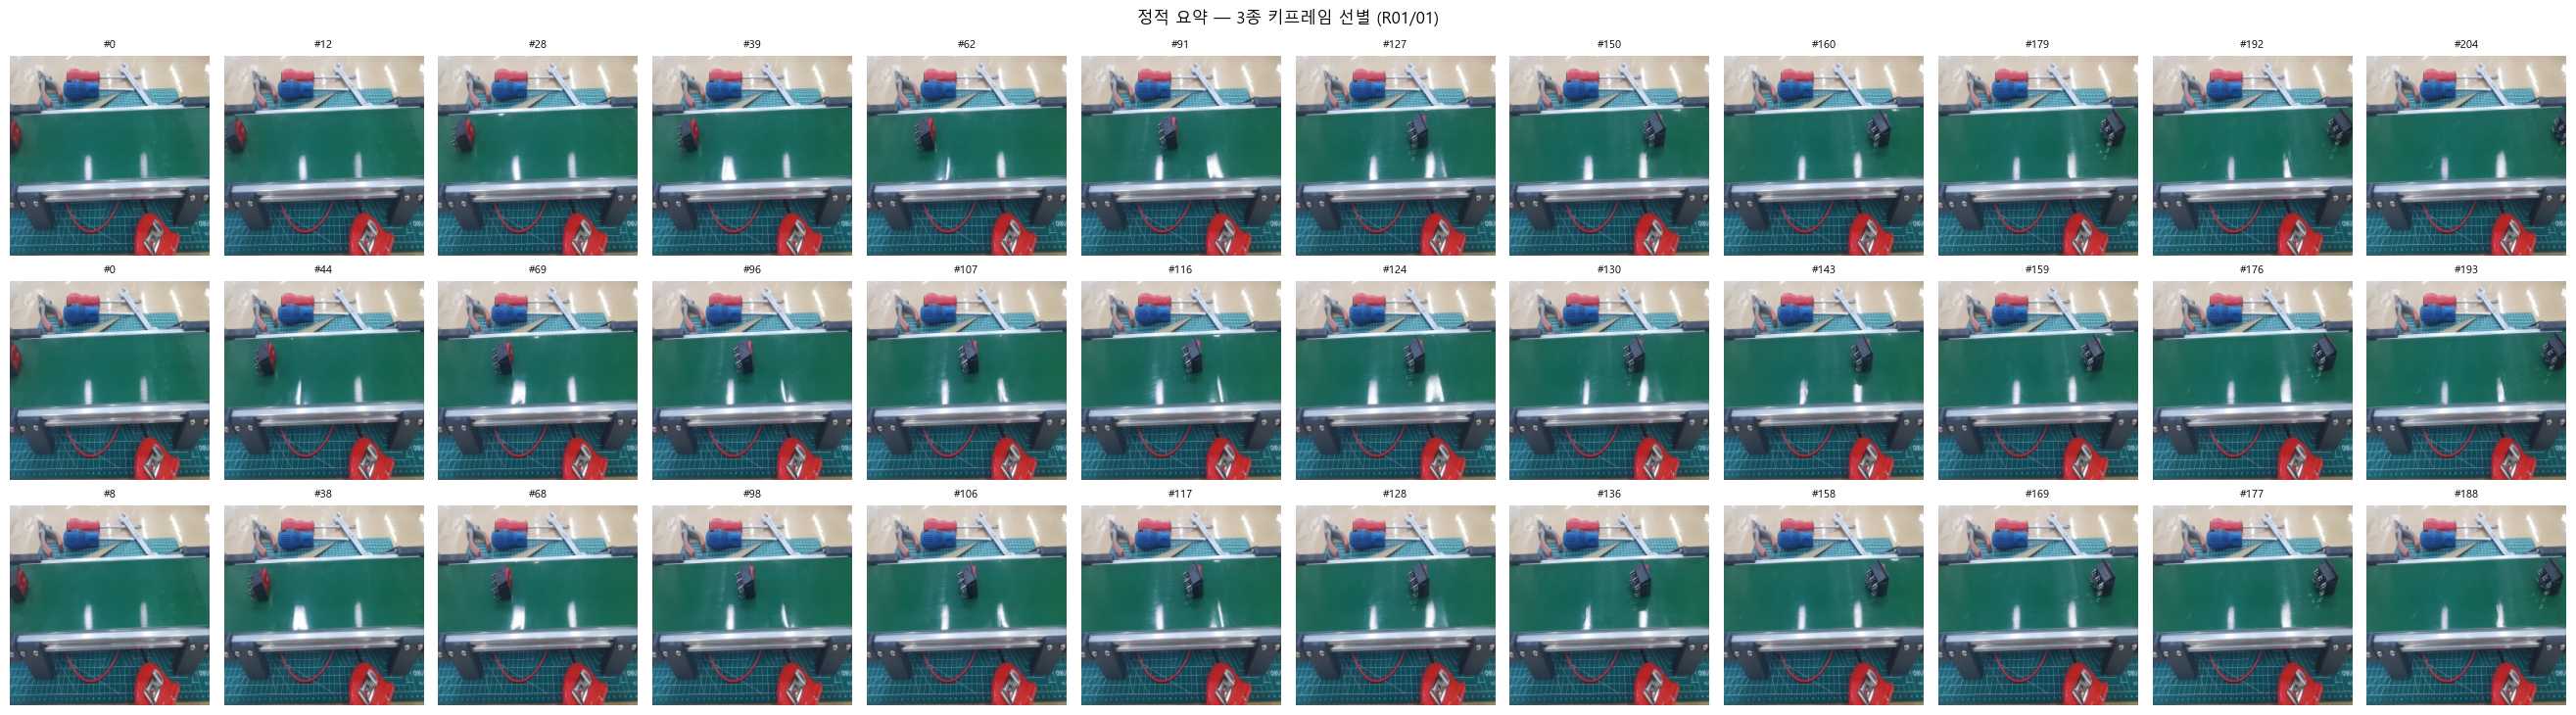

In [6]:
# ── 1-2. 정적 요약 결과 시각화 ──

def plot_keyframe_comparison(
    frames: list[np.ndarray],
    indices_dict: dict[str, list[int]],
    title: str,
    save_path: Path,
) -> None:
    """방법별 키프레임을 행(row) 단위로 나란히 표시."""
    methods = list(indices_dict.keys())
    n_cols = max(len(v) for v in indices_dict.values())
    fig, axes = plt.subplots(len(methods), n_cols, figsize=(2.2 * n_cols, 2.5 * len(methods)))
    if len(methods) == 1:
        axes = np.expand_dims(axes, 0)
    for r, (name, idxs) in enumerate(indices_dict.items()):
        for c in range(n_cols):
            ax = axes[r, c]
            ax.axis("off")
            if c < len(idxs):
                ax.imshow(frame_to_rgb(frames[idxs[c]]))
                ax.set_title(f"#{idxs[c]}", fontsize=8)
            if c == 0:
                ax.set_ylabel(name, fontsize=9, rotation=0, labelpad=50, va="center")
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    fig.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()


plot_keyframe_comparison(
    FRAMES,
    {
        "Histogram": kf_hist,
        "SSIM/MSE": kf_ssim,
        "Motion Peak": kf_motion,
    },
    f"정적 요약 — 3종 키프레임 선별 ({CLIP_META.device}/{CLIP_META.clip_id})",
    FIG_DIR / "01_static_keyframes.png",
)


In [7]:
# ── 1-3. 동적 요약: Shot Boundary + Importance Skimming ──
# 교재 '동적 요약(Video Skimming)': 중요 구간 클립을 타임라인 순으로 병합

def detect_shot_boundaries(
    frames: list[np.ndarray],
    threshold: float = SHOT_THRESHOLD,
    min_gap: int = 3,
) -> list[int]:
    """히스토그램 급변 지점 = Shot/Scene 경계."""
    if len(frames) < 2:
        return [0]
    hists = [compute_color_histogram(f) for f in frames]
    boundaries = [0]
    for i in range(1, len(hists)):
        d = histogram_distance(hists[i], hists[i - 1])
        if d >= threshold and (i - boundaries[-1]) >= min_gap:
            boundaries.append(i)
    return boundaries


@dataclass
class VideoSegment:
    """시간축上的 구간 [start, end) — start 포함, end 미포함."""
    start: int
    end: int
    importance: float = 0.0

    @property
    def length(self) -> int:
        return self.end - self.start


def segments_from_boundaries(boundaries: list[int], total: int) -> list[VideoSegment]:
    """경계 인덱스 목록 → 연속 VideoSegment 리스트."""
    bounds = sorted(set(boundaries + [total]))
    segs = []
    for s, e in zip(bounds[:-1], bounds[1:]):
        if e - s >= 1:
            segs.append(VideoSegment(s, e))
    return segs


def score_segment_importance(seg: VideoSegment, motion: np.ndarray) -> float:
    """
    구간 중요도 = motion 평균 + 0.3×peak.
    설비 동작이 활발한 구간일수록 skimming 후보.
    """
    if seg.end <= 1 or len(motion) == 0:
        return 0.0
    s = max(0, seg.start)
    e = min(len(motion), seg.end - 1)
    if s >= e:
        return 0.0
    return float(np.mean(motion[s:e]) + 0.3 * np.max(motion[s:e]))


def build_skim_timeline(
    segments: list[VideoSegment],
    top_ratio: float = 0.35,
) -> list[VideoSegment]:
    """상위 importance 구간만 선택 — Video Skimming."""
    if not segments:
        return []
    ranked = sorted(segments, key=lambda s: s.importance, reverse=True)
    k = max(1, int(len(ranked) * top_ratio))
    # 시간순 정렬 유지 → narrative flow 보존
    chosen = sorted(ranked[:k], key=lambda s: s.start)
    return chosen


boundaries = detect_shot_boundaries(FRAMES, SHOT_THRESHOLD)
segments = segments_from_boundaries(boundaries, len(FRAMES))
for seg in segments:
    seg.importance = score_segment_importance(seg, MOTION)
skim_segs = build_skim_timeline(segments, top_ratio=0.4)

print(f"Shot boundaries: {len(boundaries)} | Segments: {len(segments)} | Skim: {len(skim_segs)}")
for seg in skim_segs[:5]:
    print(f"  [{seg.start:4d}:{seg.end:4d}) importance={seg.importance:.4f}")


Shot boundaries: 1 | Segments: 1 | Skim: 1
  [   0: 207) importance=2.1823


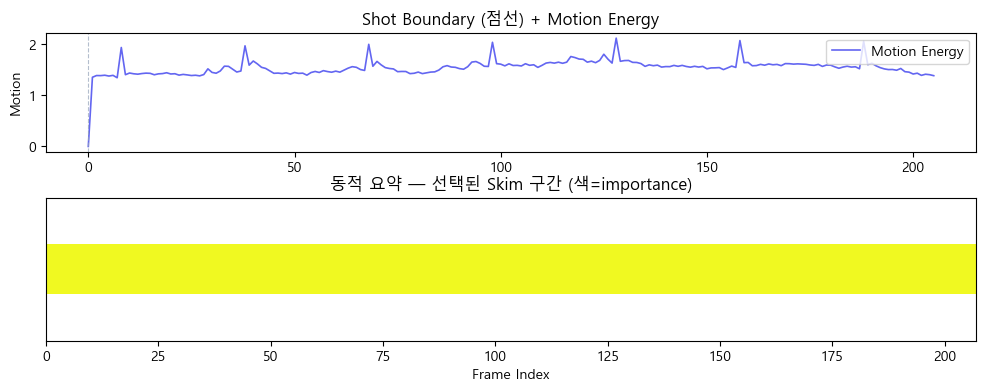

In [8]:
# ── 1-4. 동적 요약 타임라인 시각화 ──

def plot_temporal_summary_timeline(
    num_frames: int,
    boundaries: list[int],
    skim_segments: list[VideoSegment],
    motion: np.ndarray,
    save_path: Path,
) -> None:
    """상단: Motion + Shot boundary / 하단: Skim 구간 bar."""
    fig = plt.figure(figsize=(12, 4))
    gs = GridSpec(2, 1, height_ratios=[1, 1.2], hspace=0.35)

    ax0 = fig.add_subplot(gs[0])
    x = np.arange(len(motion))
    ax0.plot(x, motion, color="#6366f1", lw=1.2, label="Motion Energy")
    for b in boundaries:
        ax0.axvline(b, color="#94a3b8", ls="--", lw=0.8, alpha=0.7)
    ax0.set_ylabel("Motion")
    ax0.set_title("Shot Boundary (점선) + Motion Energy")
    ax0.legend(loc="upper right")

    ax1 = fig.add_subplot(gs[1])
    ax1.set_xlim(0, num_frames)
    ax1.set_ylim(0, 1)
    ax1.set_yticks([])
    ax1.set_xlabel("Frame Index")
    for seg in skim_segments:
        ax1.barh(0.5, seg.length, left=seg.start, height=0.35,
                 color=plt.cm.plasma(seg.importance / (max(s.importance for s in skim_segments) + 1e-6)))
    ax1.set_title("동적 요약 — 선택된 Skim 구간 (색=importance)")

    fig.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()


plot_temporal_summary_timeline(
    len(FRAMES), boundaries, skim_segs, MOTION,
    FIG_DIR / "02_dynamic_skim_timeline.png",
)


## Part 2 — VLM 융합 메커니즘 & 프레임 토큰화

**Spatial Feature Extraction → Spatiotemporal Projector → LLM Token Alignment** 3단계를
경량 코드로 재현합니다.

| 단계 | 개념 | 실습 구현 |
|------|----------|----------|
| 1 | 2D Vision Encoder (ViT) | CLIP Vision Tower |
| 2 | Q-Former + MLP Projector | `SpatiotemporalProjector` |
| 3 | LLM Token Space | cosine similarity · pseudo-token budget |

---

### 이 섹션에서 쓰는 기술 — 용어 정리

| 약어/용어 | 원문 (Full Name) | 쉬운 설명 | 코드에서 |
|-----------|------------------|-----------|----------|
| **VLM** | Vision-Language Model | **이미지(영상) + 텍스트**를 함께 이해하는 AI. “이 영상에서 무슨 일이?” 같은 질의에 답함 | Part 2~4 전반 |
| **CLIP** | Contrastive Language-Image Pre-training | 이미지·텍스트를 **같은 embedding 공간**에 맞춰 학습. “설비 동작” 같은 문장과 프레임 유사도 계산 | `encode_frames_clip`, `score_frames_with_clip` |
| **ViT** | Vision Transformer | 이미지를 patch 단위 token으로 쪼개 Transformer로 처리. CLIP vision tower의 백본 | CLIP 내부 encoder |
| **Embedding** | Embedding / Feature Vector | 이미지·텍스트를 고차원 숫자 벡터로 압축한 표현. 유사도·검색·VLM 입력의 기본 단위 | `FRAME_EMB` |
| **Spatial Feature** | Spatial Feature | **한 프레임 안**의 공간적(객체·배경) 정보. 2D Vision Encoder 출력 | CLIP image features |
| **Spatiotemporal** | Spatiotemporal | **공간(spatial) + 시간(temporal)** 을 함께 다룸. 여러 프레임 embedding을 시간 맥락과 함께 압축 | `SpatiotemporalProjector` |
| **Q-Former** | Query Transformer | 고정 개수의 **learnable query**가 긴 visual token 시퀀스에서 필요한 정보만 cross-attention으로 뽑음 | Projector의 `queries` |
| **MLP** | Multi-Layer Perceptron | 여러 층 fully-connected 신경망. visual feature를 LLM이 읽을 수 있는 차원으로 **투영(projection)** | Projector의 `mlp` |
| **LLM** | Large Language Model | GPT·LLaMA 등 대규모 **언어** 모델. VLM은 visual token을 LLM 입력처럼 넣어 서술·추론 | 토큰 alignment 개념 |
| **Token** | Token | LLM/VLM이 처리하는 최소 입력 단위(단어 piece 또는 visual patch/query). **컨텍스트 길이 = token 수** | `NUM_VLM_FRAMES`, 압축 |
| **Cross-Attention** | Cross-Attention | Query가 Key/Value(프레임 embedding)를 참조해 정보를 모음. N프레임 → K토큰 압축 핵심 | `MultiheadAttention` |
| **Cosine Similarity** | Cosine Similarity | 두 벡터 방향이 얼마나 같은지(−1~1). L2 정규화 후 내적 = cosine | CLIP relevance score |
| **Video-LLaVA** | Video Large Language and Vision Assistant | Image·Video embedding을 **공통 공간**에 정렬. Zero-shot 질의에 강한 경량 VLM | 아키텍처 비교 표 |
| **Video-LLaMA** | Video LLaMA | **영상 + 오디오 spectrogram**을 함께 인코딩해 시청각 추론 | 아키텍처 비교 표 |
| **LLaVA-Next-Video** | LLaVA-Next for Video | **장시간 영상**용 고밀도 프레임 **토큰 압축**(AnyRes·pooling). CCTV·black-box에 최적화 | `compress_frame_tokens` |
| **AnyRes** | Any Resolution | 해상도·종횡비에 유연하게 patch를 나누는 multi-scale vision 입력 전략 | LLaVA-Next-Video 전략 |
| **Zero-shot** | Zero-shot | 해당 task용 **추가 학습 없이** 프롬프트만으로 추론 | CLIP text query |

> **한 줄 요약:** 긴 영상은 프레임마다 CLIP으로 **spatial embedding**을 만들고, Projector로 **K개 visual token**으로 압축한 뒤, LLM **token 공간**에 맞춰 넣는 것이 VLM 융합의 핵심입니다. LLM 컨텍스트 한도(수천~수만 token) 때문에 압축이 필수입니다.


In [9]:
# ── 2-1. CLIP Vision Encoder — 프레임별 Spatial Embedding ──
# 교재: 2D Vision Encoder(ViT)로 프레임 spatial feature 추출

_clip_model = None
_clip_processor = None


def get_clip_model():
    """CLIP 모델·프로세서 lazy load (셀 재실행 시 캐시 재사용)."""
    global _clip_model, _clip_processor
    if _clip_model is None and RUN_CLIP:
        from transformers import CLIPModel, CLIPProcessor
        _clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
        _clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(DEVICE).eval()
    return _clip_model, _clip_processor


def _as_feature_tensor(output) -> torch.Tensor:
    """transformers 버전별 CLIP 출력 → 2D tensor."""
    if isinstance(output, torch.Tensor):
        return output
    for attr in ("image_embeds", "text_embeds", "pooler_output"):
        val = getattr(output, attr, None)
        if val is not None:
            return val
    raise TypeError(f"Unexpected CLIP output type: {type(output)}")


@torch.inference_mode()
def encode_frames_clip(frames: list[np.ndarray], batch_size: int = 16) -> np.ndarray:
    """N프레임 → (N, D) CLIP image embedding."""
    model, processor = get_clip_model()
    if model is None:
        # fallback: grayscale histogram feature
        feats = []
        for f in frames:
            h = compute_color_histogram(f, bins=16)
            feats.append(h)
        return np.stack(feats)
    all_emb = []
    for i in range(0, len(frames), batch_size):
        batch = frames[i : i + batch_size]
        images = [Image.fromarray(frame_to_rgb(f)) for f in batch]
        inputs = processor(images=images, return_tensors="pt", padding=True).to(DEVICE)
        emb = _as_feature_tensor(model.get_image_features(**inputs))
        emb = F.normalize(emb, dim=-1)  # cosine similarity용 L2 정규화
        all_emb.append(emb.cpu().numpy())
    return np.vstack(all_emb)


@torch.inference_mode()
def score_frames_with_clip(
    frames: list[np.ndarray],
    text_query: str,
) -> np.ndarray:
    """텍스트 쿼리와 프레임 relevance score (0~1)."""
    model, processor = get_clip_model()
    img_emb = encode_frames_clip(frames)
    if model is None:
        return np.linspace(0.3, 1.0, len(frames))
    inputs = processor(text=[text_query], return_tensors="pt", padding=True).to(DEVICE)
    txt_emb = _as_feature_tensor(model.get_text_features(**inputs))
    txt_emb = F.normalize(txt_emb, dim=-1).cpu().numpy()
    scores = img_emb @ txt_emb.T
    scores = scores.squeeze(-1)
    # min-max 정규화 → AKS/T* 입력 relevance
    scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-6)
    return scores.astype(np.float32)


if RUN_CLIP:
    # 임베딩 데모: 전체 중 64프레임만 (속도)
    FRAME_EMB = encode_frames_clip(FRAMES[: min(64, len(FRAMES))])
    CLIP_SCORES = score_frames_with_clip(FRAMES, SUMMARY_QUERY)
    print(f"CLIP embedding shape: {FRAME_EMB.shape}")
    print(f"CLIP relevance — top5 frames: {np.argsort(CLIP_SCORES)[-5:][::-1].tolist()}")
else:
    FRAME_EMB = encode_frames_clip(FRAMES)
    CLIP_SCORES = np.ones(len(FRAMES), dtype=np.float32)
    print("RUN_CLIP=False — histogram fallback 사용")


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP embedding shape: (64, 512)
CLIP relevance — top5 frames: [201, 10, 199, 179, 205]


In [10]:
# ── 2-2. Spatiotemporal Projector — N프레임 → K Query Token ──
# 교재: Q-Former + MLP Projector로 temporal frame embedding → 고정 query token

class SpatiotemporalProjector(nn.Module):
    """교재 Q-Former + MLP Projector 간소화: learnable query가 프레임 임베딩을 압축."""

    def __init__(self, dim: int, num_queries: int = 8, num_heads: int = 4):
        super().__init__()
        # K개 learnable query — LLM에 전달할 visual token 역할
        self.queries = nn.Parameter(torch.randn(num_queries, dim) * 0.02)
        self.cross_attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.GELU(),
            nn.Linear(dim * 2, dim),
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, frame_tokens: torch.Tensor) -> torch.Tensor:
        # frame_tokens: (B, T, D) — T=입력 프레임 수
        b, _, d = frame_tokens.shape
        q = self.queries.unsqueeze(0).expand(b, -1, -1)
        out, _ = self.cross_attn(q, frame_tokens, frame_tokens)
        out = self.norm(out + self.mlp(out))
        return out  # (B, K, D)


def compress_frame_tokens(embeddings: np.ndarray, num_tokens: int = NUM_VLM_FRAMES) -> np.ndarray:
    """고정 budget K토큰으로 압축 (LLaVA-Next-Video 토큰 압축 개념)."""
    emb = torch.from_numpy(embeddings).float().unsqueeze(0)
    dim = emb.shape[-1]
    projector = SpatiotemporalProjector(dim, num_queries=num_tokens).to(DEVICE)
    with torch.no_grad():
        compressed = projector(emb.to(DEVICE)).squeeze(0).cpu().numpy()
    return compressed


sample_emb = FRAME_EMB[: min(32, len(FRAME_EMB))]
compressed_tokens = compress_frame_tokens(sample_emb, NUM_VLM_FRAMES)
print(f"입력 프레임 토큰: {sample_emb.shape} → 압축: {compressed_tokens.shape}")
print("교재: 긴 CCTV/Black-box 영상은 토큰 압축 없이 LLM 컨텍스트를 초과합니다.")


입력 프레임 토큰: (32, 512) → 압축: (8, 512)
교재: 긴 CCTV/Black-box 영상은 토큰 압축 없이 LLM 컨텍스트를 초과합니다.


In [11]:
# ── 2-3. VLM 아키텍처 비교 ──
# 교재 Part 3: Video-LLaVA / Video-LLaMA / LLaVA-Next-Video 특성 정리

VLM_ARCHITECTURES = {
    "Video-LLaVA": {
        "fusion": "Image·Video embedding 공통 공간 정렬",
        "strength": "Zero-shot 프롬프트 응답, 경량",
        "token_strategy": "Uniform frame sampling + projection",
    },
    "Video-LLaMA": {
        "fusion": "Visual + Audio Spectrogram 상호 보완",
        "strength": "멀티모달(시청각) 추론",
        "token_strategy": "Audio encoder + visual stream 병렬",
    },
    "LLaVA-Next-Video": {
        "fusion": "고밀도 프레임 토큰 압축",
        "strength": "장시간 CCTV·Black-box 최적화",
        "token_strategy": "AnyRes + spatiotemporal pooling",
    },
}

print("=" * 72)
print(f"{'Model':<22} {'Fusion':<28} {'Token Strategy'}")
print("-" * 72)
for name, spec in VLM_ARCHITECTURES.items():
    print(f"{name:<22} {spec['fusion']:<28} {spec['token_strategy']}")
print("=" * 72)


Model                  Fusion                       Token Strategy
------------------------------------------------------------------------
Video-LLaVA            Image·Video embedding 공통 공간 정렬 Uniform frame sampling + projection
Video-LLaMA            Visual + Audio Spectrogram 상호 보완 Audio encoder + visual stream 병렬
LLaVA-Next-Video       고밀도 프레임 토큰 압축                AnyRes + spatiotemporal pooling


## Part 3 — 시간 세그멘테이션 & 적응형 키프레임

최신 Long-form VLM 전처리 기법을 **학습용 경량 구현**으로 재현합니다.

| 방법 | 논문/개념 | 핵심 아이디어 |
|------|----------|--------------|
| **Change-Point** | Shot/Scene Segmentation | 히스토그램·모션 급변 |
| **K-Medoids** | 의미 단위 클러스터 | 대표 프레임 = medoid |
| **AKS** | CVPR 2025 | relevance + temporal coverage |
| **T*** | CVPR 2025 | Temporal grid → zoom-in search |

---

### 이 섹션에서 쓰는 기술 — 용어 정리

| 약어/용어 | 원문 (Full Name) | 쉬운 설명 | 코드에서 |
|-----------|------------------|-----------|----------|
| **Segmentation** | Temporal / Video Segmentation | 긴 영상을 **의미 있는 시간 구간**으로 나누는 것. Shot·이벤트·운전 단계 단위 | `segment_by_change_points` |
| **Change-Point** | Change-Point Detection | 시계열(histogram diff, motion)에서 **통계적 성질이 바뀌는 지점**. 구간 경계 후보 | `segment_by_change_points` |
| **Scene / Shot** | Scene / Shot | 하나의 연속 촬영 또는 시각적으로 동질적인 **장면 단위**. Shot boundary = 장면 전환 | `detect_shot_boundaries` |
| **K-Medoids** | K-Medoids Clustering | K-Means와 비슷하지만 중심을 **실제 데이터점(medoid)** 으로 선택 → 대표 프레임으로 적합 | `kmedoids_indices` |
| **Medoid** | Medoid | 클러스터 내 다른 점들과의 거리 합이 최소인 **실제 샘플**. 평균(centroid)과 달리 ‘진짜 프레임’ | `representative_frames_per_segment` |
| **PAM** | Partitioning Around Medoids | K-Medoids의 대표 알고리즘. 본 코드는 경량 1-swap 근사 | `kmedoids_indices` |
| **AKS** | Adaptive Keyframe Sampling | CVPR 2025. 고정 token budget 안에서 **쿼리 relevance**와 **시간축 coverage(고르게 퍼짐)** 를 동시에 최대화 | `adaptive_keyframe_sampling` |
| **Relevance** | Relevance Score | 텍스트 질의(또는 motion)와 프레임이 **얼마나 관련 있는지** 점수. CLIP cosine → 0~1 정규화 | `CLIP_SCORES` |
| **Coverage** | Temporal Coverage | 키프레임이 영상 **전 구간에 고르게** 분포하도록 하는 제약. 한 구간만 몰리는 것 방지 | AKS의 `coverage_weight` |
| **T\*** | T-star (Temporal Search) | CVPR 2025 “Re-thinking Temporal Search”. 긴 영상을 **시간 그리드**로 보고 promising 구간만 **zoom-in** 탐색 | `temporal_grid_search` |
| **Long-form VLM** | Long-form Vision-Language Model | 수천~수만 프레임 **장영상**을 이해하려는 VLM. 전처리(선별·압축)가 성능 좌우 | Part 3 전체 |
| **CVPR** | Conference on Computer Vision and Pattern Recognition | 컴퓨터 비전 최상위 학회. AKS·T* 등 2025 SOTA 기법 출처 | 표 참고 |
| **Z-score** | Standard Score (Z-score) | (값 − 평균) / 표준편차. motion peak가 평소 대비 얼마나 큰지 | change-point의 `motion_z` |
| **Grid Search** | Grid Search | 시간축을 coarse grid로 나눈 뒤, 점수 높은 cell 주변만 촘촘히 재탐색 | T* zoom-in |

> **한 줄 요약:** Part 1은 “대표 **한 장**”, Part 3은 “대표 **구간** + **쿼리에 맞는** 프레임”을 고릅니다. **AKS**는 CLIP relevance와 시간 coverage, **T\***는 relevance 지도에서 구간을 좁혀 가며, **K-Medoids**는 각 구간의 시각적 대표 1장을 뽑습니다.


In [12]:
# ── 3-1. Change-Point 기반 시간 세그멘테이션 ──
# 히스토그램 급변 + motion z-score peak → 의미 단위 구간 분할

def segment_by_change_points(
    frames: list[np.ndarray],
    motion: np.ndarray,
    hist_threshold: float = 0.25,
    motion_z: float = 1.5,
) -> list[VideoSegment]:
    """히스토그램 변화 + 모션 z-score peak로 경계 후보 생성."""
    hists = [compute_color_histogram(f) for f in frames]
    hist_diff = np.array([
        histogram_distance(hists[i], hists[i - 1]) if i > 0 else 0.0
        for i in range(len(hists))
    ])
    motion_padded = np.concatenate([[0.0], motion]) if len(motion) else np.zeros(len(frames))
    mu, sigma = motion_padded.mean(), motion_padded.std() + 1e-6
    motion_zscore = (motion_padded - mu) / sigma

    boundaries = [0]
    for i in range(1, len(frames)):
        if hist_diff[i] >= hist_threshold or motion_zscore[i] >= motion_z:
            if i - boundaries[-1] >= MIN_SEGMENT_LEN:
                boundaries.append(i)
    segs = segments_from_boundaries(boundaries, len(frames))
    for seg in segs:
        seg.importance = score_segment_importance(seg, motion)
    return segs


cp_segments = segment_by_change_points(FRAMES, MOTION)
print(f"Change-point segments: {len(cp_segments)}")


Change-point segments: 8


In [13]:
# ── 3-2. K-Medoids — 세그먼트별 대표 프레임 ──
# 각 시간 구간에서 histogram 공간의 medoid = 시각적으로 대표되는 1장

def kmedoids_indices(dist_matrix: np.ndarray, k: int, max_iter: int = 30) -> list[int]:
    """간단 K-Medoids (PAM 1-swap 근사)."""
    n = dist_matrix.shape[0]
    k = min(k, n)
    medoids = list(np.linspace(0, n - 1, k, dtype=int))
    for _ in range(max_iter):
        clusters: dict[int, list[int]] = {m: [] for m in medoids}
        for i in range(n):
            m = min(medoids, key=lambda x: dist_matrix[i, x])
            clusters[m].append(i)
        new_medoids = []
        for m, members in clusters.items():
            if not members:
                new_medoids.append(m)
                continue
            best = min(members, key=lambda c: sum(dist_matrix[c, j] for j in members))
            new_medoids.append(best)
        if sorted(new_medoids) == sorted(medoids):
            break
        medoids = new_medoids
    return sorted(set(medoids))


def representative_frames_per_segment(
    frames: list[np.ndarray],
    segments: list[VideoSegment],
    max_per_seg: int = 1,
) -> list[int]:
    """구간별 K-Medoids 대표 프레임 → 전역 키프레임 후보."""
    reps: list[int] = []
    for seg in segments:
        idxs = list(range(seg.start, min(seg.end, len(frames))))
        if not idxs:
            continue
        if len(idxs) == 1:
            reps.append(idxs[0])
            continue
        sub_frames = [frames[i] for i in idxs]
        hists = np.stack([compute_color_histogram(f, bins=16) for f in sub_frames])
        dist = cdist(hists, hists, metric="euclidean")
        medoid_local = kmedoids_indices(dist, min(max_per_seg, len(idxs)))[:max_per_seg]
        reps.extend(idxs[i] for i in medoid_local)
    return sorted(set(reps))


seg_reps = representative_frames_per_segment(FRAMES, cp_segments[:12], max_per_seg=1)
print(f"K-Medoids 대표 프레임 ({len(seg_reps)}):", seg_reps[:12])


K-Medoids 대표 프레임 (8): [4, 25, 52, 85, 107, 152, 175, 197]


In [14]:
# ── 3-3. AKS — Adaptive Keyframe Sampling (relevance + coverage) ──
# CVPR 2025 AKS: query relevance와 시간축 coverage를 동시에 최대화

def adaptive_keyframe_sampling(
    relevance: np.ndarray,
    k: int,
    coverage_weight: float = 0.35,
) -> list[int]:
    """AKS(CVPR 2025) 아이디어: query relevance + 시간축 coverage 동시 최대화."""
    n = len(relevance)
    if n <= k:
        return list(range(n))
    time_norm = np.linspace(0, 1, n)
    selected = [int(np.argmax(relevance))]  # 가장 relevant한 프레임부터
    while len(selected) < k:
        best_idx, best_score = -1, -1e9
        for i in range(n):
            if i in selected:
                continue
            rel = relevance[i]
            # coverage: 선택된 프레임과의 최소 시간 거리
            min_dist = min(abs(time_norm[i] - time_norm[s]) for s in selected)
            score = (1 - coverage_weight) * rel + coverage_weight * min_dist
            if score > best_score:
                best_idx, best_score = i, score
        selected.append(best_idx)
    return sorted(selected)


aks_indices = adaptive_keyframe_sampling(CLIP_SCORES, NUM_KEYFRAMES, coverage_weight=0.4)
print(f"AKS keyframes ({len(aks_indices)}):", aks_indices)


AKS keyframes (12): [8, 10, 29, 38, 179, 198, 199, 201, 203, 204, 205, 206]


In [15]:
# ── 3-4. T* — Temporal Grid Search (zoom-in) ──
# CVPR 2025 T*: coarse temporal grid → promising cell 주변 upsample

def temporal_grid_search(
    relevance: np.ndarray,
    budget: int = NUM_VLM_FRAMES,
    rounds: int = 3,
    grid_cols: int = 4,
) -> list[int]:
    """T*(CVPR 2025): coarse grid → promising cell 주변 upsample."""
    n = len(relevance)
    if n <= budget:
        return list(range(n))
    candidates = list(range(n))
    for r in range(rounds):
        step = max(1, len(candidates) // (grid_cols * grid_cols))
        coarse = candidates[::step]
        if len(coarse) <= grid_cols:
            break
        # grid cell score = cell 내 relevance max
        cell_size = max(1, len(coarse) // grid_cols)
        cell_scores = []
        for c in range(grid_cols):
            s = c * cell_size
            e = min((c + 1) * cell_size, len(coarse))
            cell_idxs = coarse[s:e]
            if not cell_idxs:
                continue
            cell_scores.append((max(cell_idxs, key=lambda i: relevance[i]), max(relevance[i] for i in cell_idxs)))
        cell_scores.sort(key=lambda x: x[1], reverse=True)
        top_cells = cell_scores[: max(2, grid_cols // 2)]
        new_candidates = set()
        for anchor, _ in top_cells:
            radius = max(2, len(candidates) // (grid_cols * (r + 2)))
            for j in range(max(0, anchor - radius), min(n, anchor + radius + 1)):
                new_candidates.add(j)
        candidates = sorted(new_candidates) if new_candidates else candidates
    ranked = sorted(candidates, key=lambda i: relevance[i], reverse=True)
    return sorted(ranked[:budget])


tstar_indices = temporal_grid_search(CLIP_SCORES, budget=NUM_VLM_FRAMES)
print(f"T* search keyframes ({len(tstar_indices)}):", tstar_indices)


T* search keyframes (8): [8, 9, 10, 11, 199, 200, 201, 203]


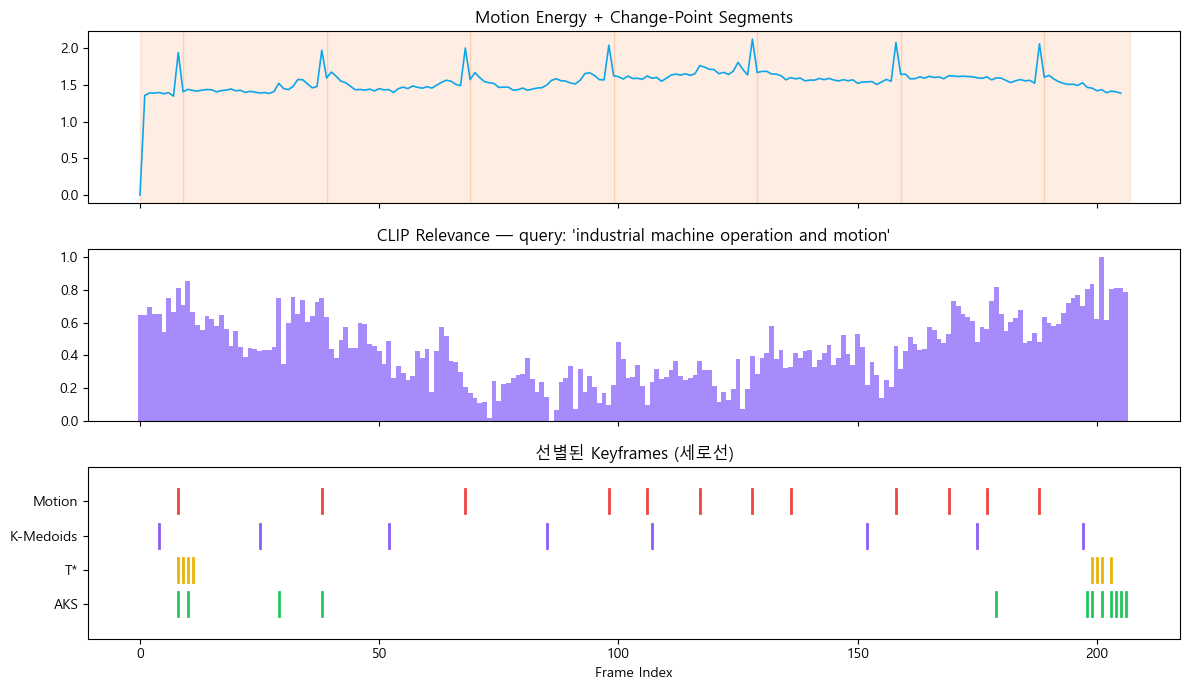

In [16]:
# ── 3-5. 세그멘테이션 + 키프레임 방법 비교 시각화 ──

def plot_segmentation_overview(
    motion: np.ndarray,
    segments: list[VideoSegment],
    method_indices: dict[str, list[int]],
    save_path: Path,
) -> None:
    """Motion+구간 / CLIP relevance / 방법별 키프레임 위치 3단 비교."""
    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(motion, color="#0ea5e9", lw=1.2)
    axes[0].set_title("Motion Energy + Change-Point Segments")
    for seg in segments:
        axes[0].axvspan(seg.start, seg.end, alpha=0.12, color="#f97316")

    axes[1].bar(np.arange(len(CLIP_SCORES)), CLIP_SCORES, color="#a78bfa", width=1.0)
    axes[1].set_title(f"CLIP Relevance — query: '{SUMMARY_QUERY}'")

    axes[2].set_ylim(0, len(method_indices) + 1)
    axes[2].set_yticks(range(1, len(method_indices) + 1))
    axes[2].set_yticklabels(list(method_indices.keys()))
    axes[2].set_xlabel("Frame Index")
    axes[2].set_title("선별된 Keyframes (세로선)")
    colors = ["#ef4444", "#22c55e", "#eab308", "#8b5cf6"]
    for yi, (name, idxs) in enumerate(method_indices.items(), start=1):
        for idx in idxs:
            axes[2].plot([idx, idx], [yi - 0.35, yi + 0.35], color=colors[yi % len(colors)], lw=2)

    plt.tight_layout()
    fig.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()


plot_segmentation_overview(
    MOTION,
    cp_segments,
    {
        "AKS": aks_indices,
        "T*": tstar_indices,
        "K-Medoids": seg_reps[:NUM_KEYFRAMES],
        "Motion": kf_motion,
    },
    FIG_DIR / "03_segmentation_keyframes.png",
)


## Part 4 — VLM 기반 통합 요약 파이프라인

1. **세그멘테이션** → Change-point + Shot boundary
2. **적응형 선별** → AKS / T* / CLIP relevance
3. **토큰 압축** → Spatiotemporal Projector
4. **텍스트 요약** → BLIP 캡션 (선택) + rule-based narrative

---

### 이 섹션에서 쓰는 기술 — 용어 정리

| 약어/용어 | 원문 (Full Name) | 쉬운 설명 | 코드에서 |
|-----------|------------------|-----------|----------|
| **Pipeline** | Processing Pipeline | 데이터 로드 → 분석 → 선별 → 저장까지 **한 번에 이어지는 처리 흐름** | `run_vlm_summary_pipeline` |
| **Manifest** | Manifest (metadata file) | 분석 결과·키프레임 경로·구간 정보를 **JSON으로 기록**한 목록 파일. 재현·배포용 | `summary_manifest.json` |
| **Rule-based Summary** | Rule-based Text Summarization | LLM 없이 **규칙(구간 수, peak, indices)** 으로 텍스트 요약 생성. 베이스라인·디버깅용 | `build_rule_based_summary` |
| **BLIP** | Bootstrapping Language-Image Pre-training | 이미지 → **자연어 캡션** 생성 모델. VLM의 ‘한 줄 설명’ 보조 | `caption_frame` (`RUN_BLIP=True`) |
| **Caption** | Image/Video Captioning | 프레임 내용을 **문장으로 서술**. “A machine is moving…” 형태 | BLIP `generate` |
| **Export** | Artifact Export | 선별 키프레임 jpg·그래프·JSON을 디스크에 **내보내기** | `export_summary_artifacts` |
| **VLM Input Card** | VLM Input Visualization | LLM/VLM에 실제로 들어갈 **키프레임 + 메타**를 한눈에 보는 시각화 | `plot_vlm_input_card` |
| **Budget** | Frame / Token Budget | VLM에 넣을 수 있는 **최대 프레임·token 수** (본 실습: `NUM_VLM_FRAMES=8`) | pipeline·AKS·T* |
| **Query** | Text Query / Prompt | “industrial machine operation…”처럼 **무엇을 찾을지** 알려 주는 텍스트. CLIP·AKS relevance 기준 | `SUMMARY_QUERY` |
| **Dataclass** | Data Class | `VideoSummaryResult`처럼 필드가 고정된 **결과 구조체**. manifest 직렬화에 사용 | `@dataclass` |
| **Interpolation** | Linear Interpolation | relevance 길이가 프레임 수와 다를 때 **프레임 축에 맞게 보간** | `np.interp` in pipeline |

#### 파이프라인 흐름 (개념도)

```
IPAD 프레임 ─→ Motion / Shot / Change-point ─→ CLIP relevance
       │                                              │
       └──────────────→ AKS 키프레임 선별 ←───────────┘
                              │
                              ▼
                    CLIP embedding → Projector(K tokens)
                              │
                              ▼
              Rule-based 요약 (+ 선택: BLIP 캡션)
                              │
                              ▼
              keyframes/*.jpg + summary_manifest.json
```

> **한 줄 요약:** Part 1~3의 기법을 **하나의 함수**로 묶어, “어떤 프레임을 VLM에 넣을지”와 “사람이 읽을 요약 텍스트·파일”까지 한 번에 만듭니다. 실무에서는 manifest와 키프레임 export가 **다운스트림 VLM(Video-LLaVA 등) 연동**의 입력이 됩니다.


In [17]:
# ── 4-1. 통합 파이프라인 ──
# 세그멘테이션 → 적응형 키프레임 → 토큰 압축 → 텍스트 요약

@dataclass
class VideoSummaryResult:
    """파이프라인 최종 산출물 — manifest JSON 직렬화 대상."""
    clip_id: str
    num_frames: int
    boundaries: list[int]
    segments: list[dict]
    keyframe_methods: dict[str, list[int]]
    vlm_frames: list[int]
    compressed_token_shape: list[int]
    text_summary: str
    query: str


_blip_model = None
_blip_processor = None


def get_blip_model():
    """BLIP 캡션 모델 lazy load (RUN_BLIP=True일 때만)."""
    global _blip_model, _blip_processor
    if _blip_model is None and RUN_BLIP:
        from transformers import BlipForConditionalGeneration, BlipProcessor
        _blip_processor = BlipProcessor.from_pretrained(BLIP_MODEL_ID)
        _blip_model = BlipForConditionalGeneration.from_pretrained(BLIP_MODEL_ID).to(DEVICE).eval()
    return _blip_model, _blip_processor


@torch.inference_mode()
def caption_frame(frame_bgr: np.ndarray) -> str:
    """단일 프레임 BLIP 캡션 생성."""
    model, processor = get_blip_model()
    if model is None:
        return "BLIP 비활성 — Motion/CLIP 기반 서술 사용"
    image = Image.fromarray(frame_to_rgb(frame_bgr))
    inputs = processor(image, return_tensors="pt").to(DEVICE)
    out = model.generate(**inputs, max_new_tokens=40)
    return processor.decode(out[0], skip_special_tokens=True)


def build_rule_based_summary(
    frames: list[np.ndarray],
    selected_indices: list[int],
    segments: list[VideoSegment],
    motion: np.ndarray,
    query: str,
) -> str:
    """규칙 기반 텍스트 요약 — VLM 없이도 재현 가능한 narrative."""
    lines = [
        f"[Video Summary] query='{query}'",
        f"- 전체 {len(frames)}프레임, {len(segments)}개 시간 구간으로 분할",
    ]
    top_seg = sorted(segments, key=lambda s: s.importance, reverse=True)[:3]
    for i, seg in enumerate(top_seg, 1):
        t0 = seg.start / FPS_ASSUMED
        t1 = seg.end / FPS_ASSUMED
        lines.append(f"- 구간{i}: {t0:.1f}s~{t1:.1f}s | importance={seg.importance:.3f}")
    lines.append(f"- VLM 입력 키프레임 {len(selected_indices)}장: indices={selected_indices}")
    if len(motion):
        peak = int(np.argmax(motion))
        lines.append(f"- 최대 motion peak: frame #{peak} ({peak/FPS_ASSUMED:.1f}s)")
    return "\n".join(lines)


def run_vlm_summary_pipeline(
    frames: list[np.ndarray],
    clip_meta: IpadClip,
    query: str = SUMMARY_QUERY,
    num_vlm_frames: int = NUM_VLM_FRAMES,
) -> VideoSummaryResult:
    """전체 VLM 요약 워크플로: 선별 → 압축 → 요약 텍스트."""
    motion = compute_motion_energy(frames)
    bounds = detect_shot_boundaries(frames)
    segs = segments_from_boundaries(bounds, len(frames))
    for seg in segs:
        seg.importance = score_segment_importance(seg, motion)
    cp_segs = segment_by_change_points(frames, motion)

    relevance = score_frames_with_clip(frames, query) if RUN_CLIP else motion / (motion.max() + 1e-6)
    if len(relevance) < len(frames):
        relevance = np.interp(np.arange(len(frames)), np.arange(len(relevance)), relevance)

    methods = {
        "histogram": select_keyframes_histogram(frames, num_vlm_frames),
        "aks": adaptive_keyframe_sampling(relevance, num_vlm_frames),
        "tstar": temporal_grid_search(relevance, budget=num_vlm_frames),
        "motion": select_keyframes_motion_topk(frames, motion, num_vlm_frames),
    }
    vlm_frames = methods["aks"]  # 기본 VLM 입력: AKS 선별 결과

    emb = encode_frames_clip([frames[i] for i in vlm_frames])
    compressed = compress_frame_tokens(emb, num_vlm_frames)

    text = build_rule_based_summary(frames, vlm_frames, segs, motion, query)
    if RUN_BLIP and vlm_frames:
        cap = caption_frame(frames[vlm_frames[len(vlm_frames) // 2]])
        text += f"\n- BLIP 캡션(중앙 키프레임): {cap}"

    return VideoSummaryResult(
        clip_id=f"{clip_meta.device}_{clip_meta.split}_{clip_meta.clip_id}",
        num_frames=len(frames),
        boundaries=bounds,
        segments=[{"start": s.start, "end": s.end, "importance": round(s.importance, 4)} for s in segs],
        keyframe_methods=methods,
        vlm_frames=vlm_frames,
        compressed_token_shape=list(compressed.shape),
        text_summary=text,
        query=query,
    )


summary_result = run_vlm_summary_pipeline(FRAMES, CLIP_META, SUMMARY_QUERY)
print(summary_result.text_summary)


[Video Summary] query='industrial machine operation and motion'
- 전체 207프레임, 1개 시간 구간으로 분할
- 구간1: 0.0s~6.9s | importance=2.182
- VLM 입력 키프레임 8장: indices=[8, 10, 38, 179, 199, 201, 204, 205]
- 최대 motion peak: frame #128 (4.3s)


In [18]:
# ── 4-2. 키프레임 export + manifest 저장 ──

def export_summary_artifacts(result: VideoSummaryResult, frames: list[np.ndarray]) -> Path:
    """VLM 입력 키프레임 jpg 저장 + summary_manifest.json 기록."""
    clip_dir = KEYFRAME_DIR / result.clip_id
    clip_dir.mkdir(parents=True, exist_ok=True)
    for i, idx in enumerate(result.vlm_frames):
        out = clip_dir / f"keyframe_{i:02d}_f{idx:04d}.jpg"
        cv2.imwrite(str(out), frames[idx])
    payload = {
        "clip_id": result.clip_id,
        "query": result.query,
        "num_frames": result.num_frames,
        "boundaries": result.boundaries,
        "segments": result.segments,
        "keyframe_methods": result.keyframe_methods,
        "vlm_frames": result.vlm_frames,
        "compressed_token_shape": result.compressed_token_shape,
        "text_summary": result.text_summary,
    }
    MANIFEST_PATH.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    return MANIFEST_PATH


manifest_path = export_summary_artifacts(summary_result, FRAMES)
print(f"Manifest 저장: {manifest_path}")


Manifest 저장: output_vlm_summary\summary_manifest.json


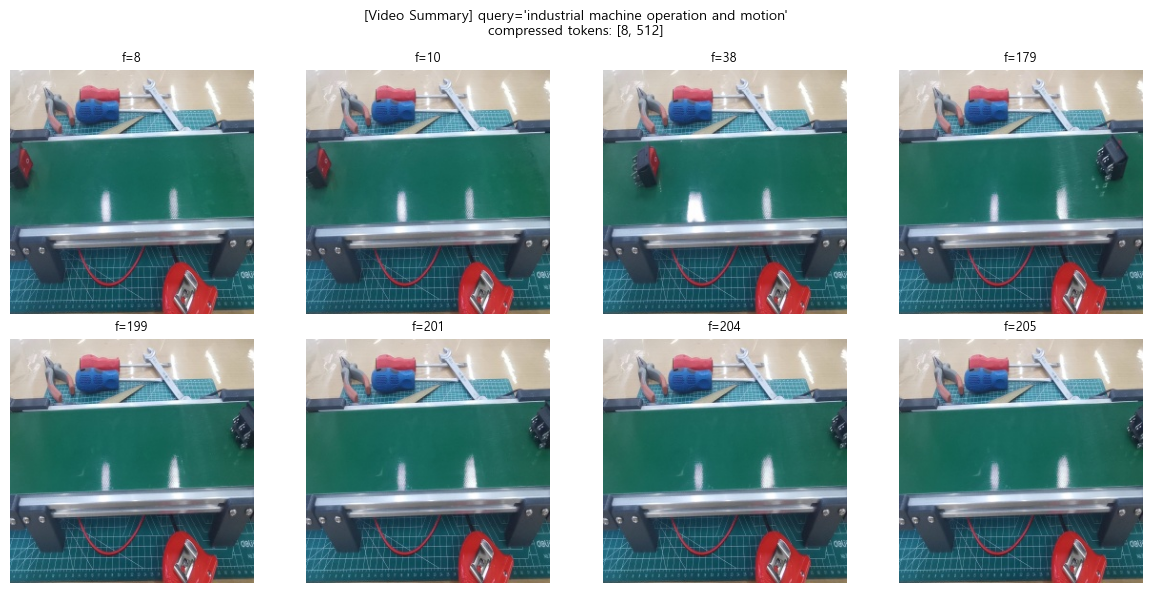

In [19]:
# ── 4-3. VLM 입력 카드 — 선별 프레임 + 요약 텍스트 ──

def plot_vlm_input_card(result: VideoSummaryResult, frames: list[np.ndarray], save_path: Path) -> None:
    """LLM/VLM에 실제로 들어갈 키프레임 + 요약 메타를 한 장 카드로 시각화."""
    idxs = result.vlm_frames
    n = len(idxs)
    cols = min(4, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.atleast_2d(axes)
    for i in range(rows * cols):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        ax.axis("off")
        if i < n:
            ax.imshow(frame_to_rgb(frames[idxs[i]]))
            ax.set_title(f"f={idxs[i]}", fontsize=9)
    fig.suptitle(
        textwrap.fill(result.text_summary.split("\n")[0], 80) + "\n" +
        f"compressed tokens: {result.compressed_token_shape}",
        fontsize=10,
    )
    plt.tight_layout()
    fig.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()


plot_vlm_input_card(summary_result, FRAMES, FIG_DIR / "04_vlm_input_card.png")


# 전체 요약

- **Part 1** — 정적(Keyframe: Histogram/SSIM/Motion) vs 동적(Shot boundary + Skimming) 요약
- **Part 2** — CLIP Vision Encoder · Spatiotemporal Projector · VLM 3종 아키텍처 비교
- **Part 3** — Change-point 세그멘테이션 · K-Medoids · AKS · T* 적응형 키프레임
- **Part 4** — 통합 파이프라인 → 키프레임 export · manifest JSON · VLM 입력 카드

### 확장 실습
- `RUN_BLIP=True`로 BLIP-2 캡션 생성
- `SUMMARY_QUERY`를 설비 이상 상황 질의로 변경 후 AKS/T* 비교
- Video-LLaVA / LLaVA-Next-Video HuggingFace 모델로 동일 키프레임 전달
